In [4]:
import pandas as pd
import os
df=pd.read_csv("C:/Users/SHRUTI/OneDrive/Desktop/Pandas_Dataframe/APL_Logistics.csv",
               encoding="latin1")
               
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
cols=["Sales","Order Profit Per Order","Order Item Discount","Order Item Discount Rate","Order Item Product Price"]
for col in cols:
    df[col]=pd.to_numeric(df[col],errors="coerce")
df=df[df["Sales"]>0]
df["Profit Margin %"]=(df["Order Profit Per Order"]/df["Sales"])*100
os.makedirs("data", exist_ok=True)
df.to_csv("data/cleaned_data.csv",index=False)
print("Data Cleaning Completed!")

Data Cleaning Completed!


In [5]:
total_revenue=df["Sales"].sum()
total_profit=df["Order Profit Per Order"].sum()
profir_margin=(total_profit/total_revenue)*100
total_customers=df["Customer Id"].nunique()
total_products=df["Product Name"].nunique()
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode', 'Profit Margin %']


In [6]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6929653.50
Perfect Fitness Perfect Rip Deck                 4421143.02
Diamondback Women's Serene Classic Comfort Bi    4118425.42
Nike Men's Free 5.0+ Running Shoe                3667633.20
Nike Men's Dri-FIT Victory Golf Polo             3147800.00
Pelican Sunstream 100 Kayak                      3099845.00
Nike Men's CJ Elite 2 TD Football Cleat          2891757.54
O'Brien Men's Neoprene Life Vest                 2888993.94
Under Armour Girls' Toddler Spine Surge Runni    1269082.65
Dell Laptop                                       663000.00
Name: Sales, dtype: float64


In [7]:
top_customers = df.groupby("Order Customer Id")["Order Profit Per Order"].sum().sort_values(ascending=False).head(10)
print(top_customers)

Order Customer Id
2641     2441.97
1657     2196.92
9833     1938.39
2626     1928.57
5004     1917.99
3735     1906.36
749      1855.15
5560     1831.46
10967    1822.33
5053     1813.34
Name: Order Profit Per Order, dtype: float64


In [8]:
category_sales = df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category Name
Fishing                 6929653.50
Cleats                  4431942.66
Camping & Hiking        4118425.42
Cardio Equipment        3694843.20
Women's Apparel         3147800.00
Water Sports            3113844.60
Men's Footwear          2891757.54
Indoor/Outdoor Games    2888993.94
Shop By Sport           1309522.02
Computers                663000.00
Electronics              371034.64
Cameras                  267607.68
Garden                   257768.72
Children's Clothing      231757.90
Crafts                   221971.88
Girls' Apparel           151706.20
Women's Clothing         139851.36
Accessories              133671.51
Sporting Goods           117006.75
Golf Gloves              116695.39
Music                    113122.10
Consumer Electronics     108485.52
Golf Shoes               107998.00
Health and Beauty        106080.48
Kids' Golf Clubs          98797.58
Baseball & Softball       94057.15
Boxing & MMA              85205.41
DVDs                      79395.54
Golf B

In [9]:
market_profit = df.groupby("Market")["Order Profit Per Order"].sum().sort_values(ascending=False)
print(market_profit)

Market
Europe          1168862.53
LATAM           1123321.61
Pacific Asia     857473.82
USCA             564313.78
Africa           252071.18
Name: Order Profit Per Order, dtype: float64


1. Top 10 Customers
The top 10 customers contribute a significant portion of the company's total sales.
Retaining these high-value customers can improve long-term business growth and profitability.

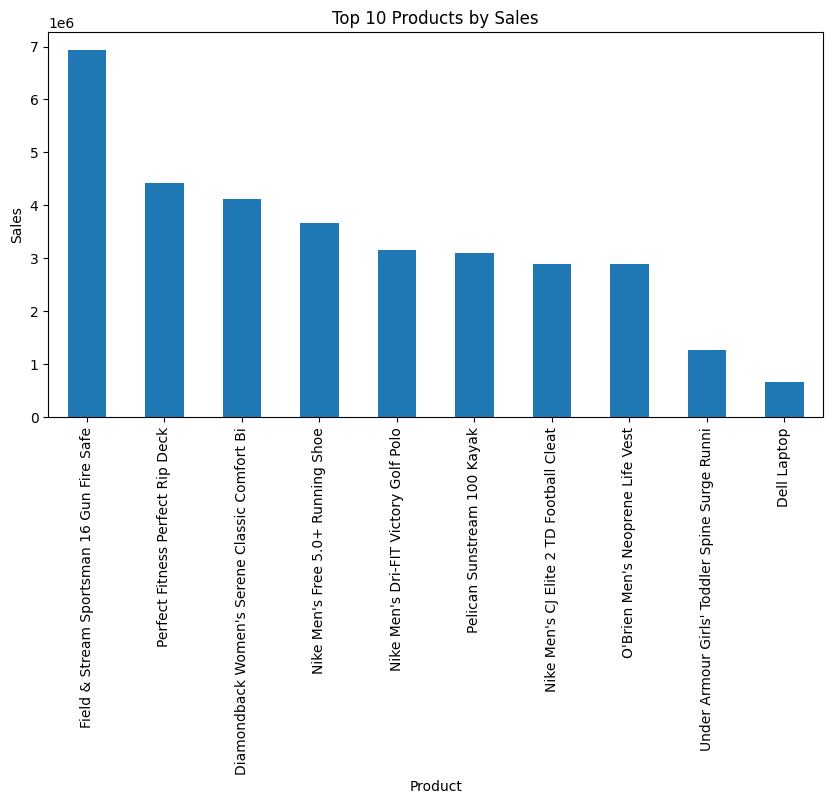

In [12]:
import matplotlib.pyplot as plt

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

In [10]:
region_sales = df.groupby("Order Region")["Sales"].sum().sort_values(ascending=False)
print(region_sales)

Order Region
Western Europe     5893666.30
Central America    5665711.99
South America      2960881.35
Northern Europe    2155012.03
Southern Europe    2047665.90
Oceania            2016654.16
Southeast Asia     1931525.76
Caribbean          1651019.30
West of USA        1571415.93
South Asia         1553465.07
Eastern Asia       1485939.83
East of USA        1371111.96
West Asia          1174671.76
US Center          1151355.75
South of  USA       785783.93
Eastern Europe      774266.55
West Africa         727951.18
North Africa        634752.21
East Africa         376234.89
Central Africa      327263.01
Southern Africa     228251.59
Canada              186861.04
Central Asia        109839.93
Name: Sales, dtype: float64


In [11]:
discount_analysis = df.groupby("Order Item Discount Rate")["Order Profit Per Order"].mean()
print(discount_analysis)

Order Item Discount Rate
0.00    26.666574
0.01    23.798759
0.02    23.675102
0.03    22.183212
0.04    23.394571
0.05    23.777867
0.06    24.038787
0.07    23.273820
0.09    22.897585
0.10    22.117119
0.12    20.914503
0.13    21.378961
0.15    20.059624
0.16    20.880197
0.17    19.339668
0.18    20.283454
0.20    17.680002
0.25    19.129471
Name: Order Profit Per Order, dtype: float64


2. Category-wise Sales
The highest-selling category generates the maximum revenue for the company.
Categories with lower sales may require better marketing strategies and promotional activities.

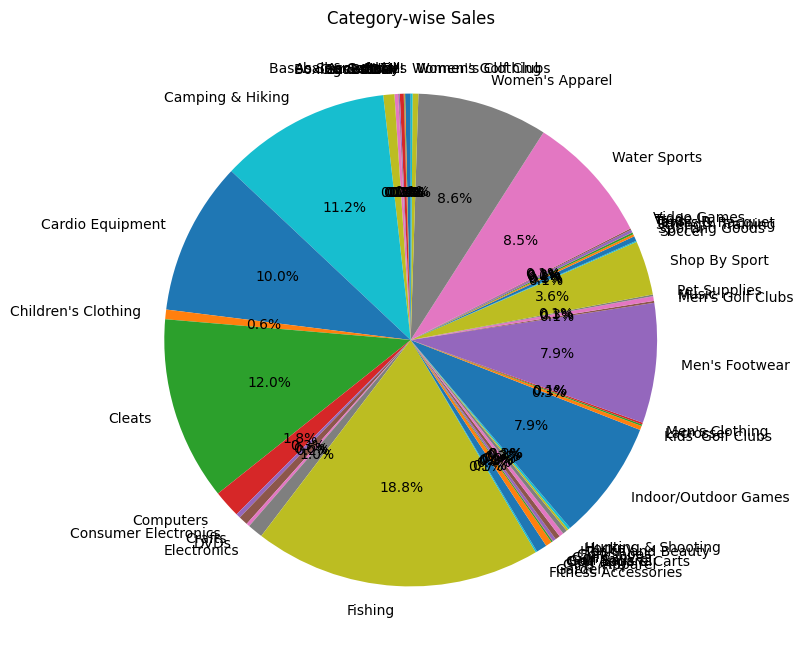

In [13]:
import matplotlib.pyplot as plt

category_sales = df.groupby("Category Name")["Sales"].sum()

plt.figure(figsize=(8,8))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Category-wise Sales")
plt.show()

3. Market-wise Profit
The most profitable market contributes the highest overall profit.
Markets with lower profitability should be analyzed to improve pricing and operational strategies.

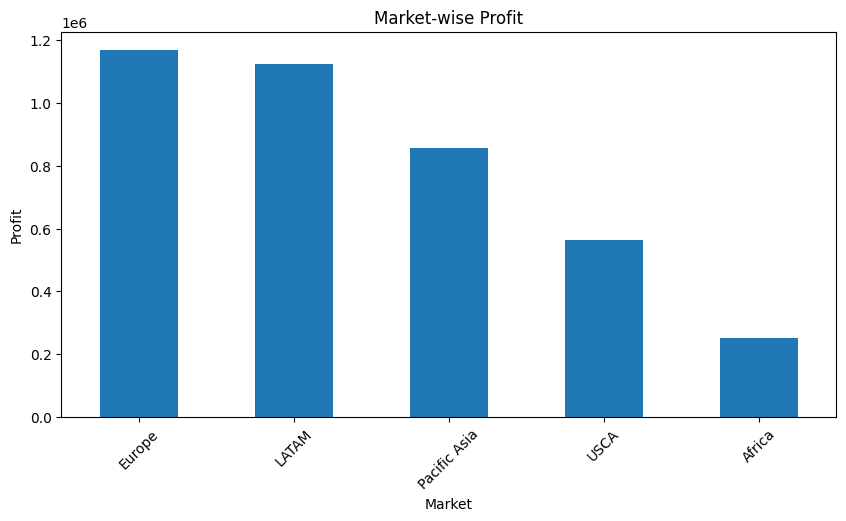

In [14]:
import matplotlib.pyplot as plt

market_profit = df.groupby("Market")["Order Profit Per Order"].sum().sort_values(ascending=False)

market_profit.plot(kind='bar', figsize=(10,5))
plt.title("Market-wise Profit")
plt.xlabel("Market")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

4. Region-wise Sales
The best-performing region records the highest sales.
Low-performing regions may need targeted marketing and improved supply chain operations.

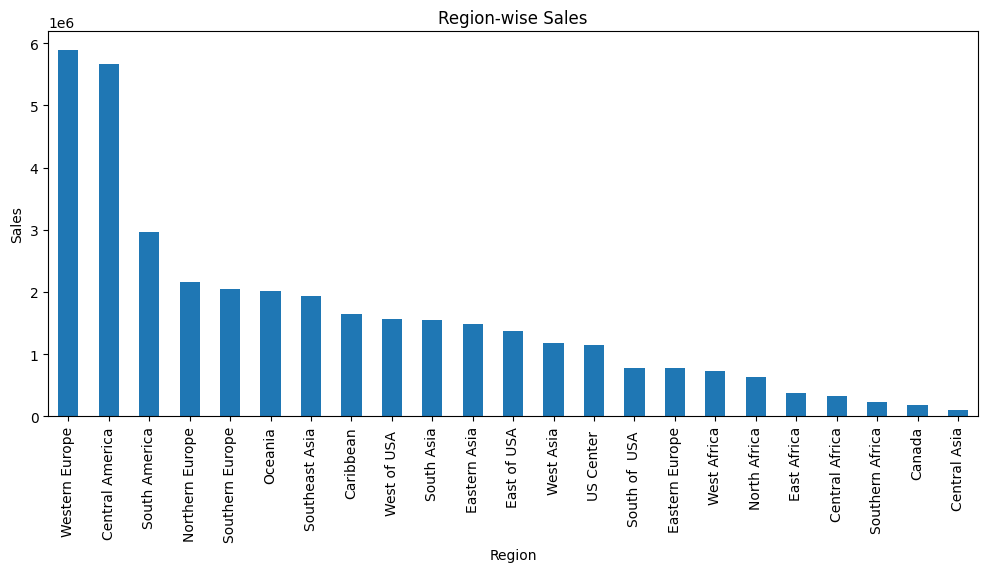

In [15]:
import matplotlib.pyplot as plt

region_sales = df.groupby("Order Region")["Sales"].sum().sort_values(ascending=False)

region_sales.plot(kind='bar', figsize=(12,5))
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

5. Discount vs Profit
Higher discount rates generally lead to lower profit margins.
Optimizing the discount strategy can help maintain profitability while attracting customers.

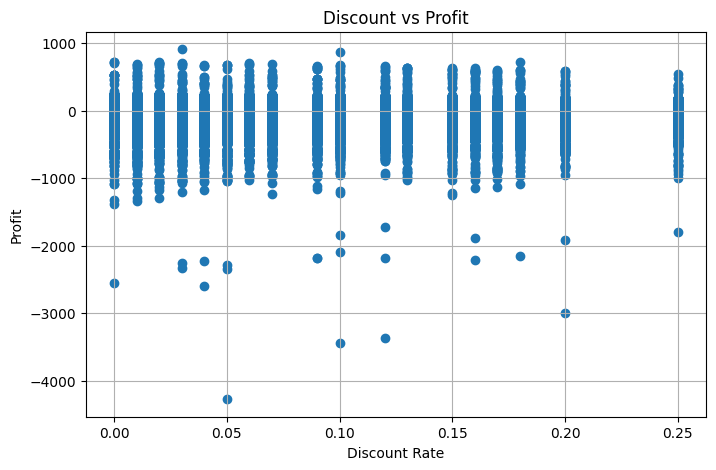

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["Order Item Discount Rate"],
            df["Order Profit Per Order"])

plt.title("Discount vs Profit")
plt.xlabel("Discount Rate")
plt.ylabel("Profit")
plt.grid(True)
plt.show()